Parameter Fitting
===

This notebook loads pre-built workspaces (from `workspace_building.ipynb`) and performs statistical inference:
1. Construct the `sbi_parametric_model` (JAX JIT-compiled NLL)
2. Minimize the NLL with `iminuit`
3. Run profile likelihood scans
4. Compare NSBI vs histogram-only sensitivity

The workspace JSON files contain everything needed — no config files or ROOT files required at fit time.

In [1]:
import os, sys
import pprint
import argparse
import logging
import warnings
import matplotlib.pyplot as plt
import mplhep as hep
import yaml
import jax

import nsbi_common_utils

jax.config.update("jax_enable_x64", True)

# Set Style
hep.style.use(hep.style.ATLAS)

In [2]:
# Configuration — edit these paths to point to your saved workspaces
hist_workspace_path = "./workspaces/workspace_histogram.json"
nsbi_workspace_path = "./workspaces/workspace_nsbi.json"
measurement = "higgs_tautau_signal_strength"
plots_dir = "./output/plots"

os.makedirs(plots_dir, exist_ok=True)

In [3]:
print("Starting Inference")
print(f"Workspaces: Histogram = {hist_workspace_path}, NSBI = {nsbi_workspace_path}")

Starting Inference
Workspaces: Histogram = ./workspaces/workspace_histogram.json, NSBI = ./workspaces/workspace_nsbi.json


In [4]:
print(f"Performing a fit for the measurement: {measurement}")

Performing a fit for the measurement: higgs_tautau_signal_strength


Loading Workspaces
--

Load the pre-built workspace JSON files. These were created in `workspace_building.ipynb` using `WorkspaceBuilder.dump_workspace()`.

In [5]:
ws_hist = nsbi_common_utils.workspace_builder.WorkspaceBuilder.load_workspace(hist_workspace_path)
print(f"Loaded histogram workspace: {len(ws_hist['channels'])} channels")

Loaded histogram workspace: 3 channels


In [6]:
ws_nsbi = nsbi_common_utils.workspace_builder.WorkspaceBuilder.load_workspace(nsbi_workspace_path)
print(f"Loaded NSBI workspace: {len(ws_nsbi['channels'])} channels")

Loaded NSBI workspace: 3 channels


The Model
-

Now lets take a look at how this workspace looks like. It is almost identical to the `pyhf` workspace schema, except it allows for analysis regions with NSBI-type fits. 

In [7]:
print(f"The NSBI fit workspace is \n\n")
pprint.pprint(ws_nsbi)

The NSBI fit workspace is 


{'channels': [{'name': 'CR',
               'samples': [{'data': [512.93359375, 55316.40234375, 625509.5],
                            'modifiers': [{'data': None,
                                           'name': 'mu_ztautau',
                                           'type': 'normfactor'},
                                          {'data': {'hi_data': [0.9936935901641846,
                                                                0.9954632520675659,
                                                                0.99919593334198],
                                                    'lo_data': [1.009008765220642,
                                                                1.0038515329360962,
                                                                1.0007826089859009]},
                                           'name': 'JES',
                                           'type': 'normplusshape'},
                                          {'d

The `nsbi_common_utils.models.sbi_parametric_model` can take as input this serialized workspace and build a likelihood model in JAX, with just-in-time (JIT) compilation. 

In [8]:
# model.Model returns the negative log-likelihood 
model_hist = nsbi_common_utils.models.sbi_parametric_model(workspace=ws_hist, 
                                                            measurement_to_fit=measurement)
        
model_nsbi = nsbi_common_utils.models.sbi_parametric_model(workspace=ws_nsbi, 
                                                            measurement_to_fit=measurement)

In [9]:
list_params, init_values = model_hist.get_model_parameters()
num_unconstrained = model_hist.num_unconstrained_param

Having processed all the inputs needed, we pass the likelihood model `nsbi_common_utils.models.sbi_parametric_model` that builds

$$\text{NLL} = -2 \cdot \log \text{Pois}(\mathcal{N}_\text{evts}|\mu, \alpha) - 2\log \frac{p(x|\mu, \alpha)}{p_{ref}(x)} + \sum_p^{N_\text{systs}} \alpha_p^2 $$

with

$$\frac{p(x|\mu, \alpha)}{p_{ref}(x)} = \frac{1}{\sum_c G_c(\alpha) \cdot f_c(\mu) \cdot \nu_c} \sum_c f_c(\mu) \cdot G_c(\alpha) \cdot \nu_c \cdot g_c(x|\alpha) \cdot \frac{p_c\left(x\right)}{p_{ref}(x)}$$

to the `inference` class of `nsbi_common_utils/inference.py` for fitting. The fitting step uses `iminuit` to minimize the NLL and build the profile negative log-likelihood test statistic:

$$t_\mu = -2 \cdot \frac{\text{Pois}(\mathcal{N}_\text{evts}|\mu, \hat{\hat{\alpha}})}{\text{Pois}(\mathcal{N}_\text{evts}|\hat{\mu}, \hat{\alpha})} -2 \cdot \sum_i^{\mathcal{N}_\text{evts}} w_i \times \log \frac{p(x_i|\mu, \hat{\hat{\alpha}})/p_{ref}(x)}{p(x_i|\hat{\mu}, \hat{\alpha})/p_{ref}(x)} + \sum_p^{N_\text{systs}} \hat{\hat{\alpha}}_p^2 - \hat{\alpha}_p^2$$



In [10]:
inf_hist = nsbi_common_utils.inference.inference(
            model_nll=model_hist.model,
            initial_values=init_values,
            list_parameters=list_params,
            num_unconstrained_params=num_unconstrained
        )

inf_nsbi = nsbi_common_utils.inference.inference(
            model_nll=model_nsbi.model,
            initial_values=init_values,
            list_parameters=list_params,
            num_unconstrained_params=num_unconstrained
        )

In [11]:
freeze_params = []

In [12]:
print("\n" + "="*40)
print(" NSBI FIT RESULTS ")
print("="*40 + "\n")
inf_nsbi.perform_fit(freeze_params=freeze_params)


 NSBI FIT RESULTS 

fit: 
 ┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -2.644e+07                 │              Nfcn = 145              │
│ EDM = 0.000515 (Goal: 0.0002)    │           time = 90.8 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬────────────┬───────────┬───────────┬────────────┬─────

In [13]:
print("\n" + "="*40)
print(" HISTOGRAM FIT RESULTS ")
print("="*40 + "\n")
inf_hist.perform_fit(freeze_params=freeze_params)


 HISTOGRAM FIT RESULTS 

fit: 
 ┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -2.385e+07                 │              Nfcn = 130              │
│ EDM = 1.51e-05 (Goal: 0.0002)    │            time = 0.3 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬────────────┬───────────┬───────────┬────────────┬

In [14]:
scan_points_hist, NLL_value_hist, scan_points_StatOnly_hist, NLL_value_StatOnly_hist = inf_hist.perform_profile_scan(parameter_name = 'mu_htautau', 
                             freeze_params = freeze_params, 
                             bound_range = (0.0, 3.0), 
                             fit_strategy = 0, 
                             doStatOnly = True,
                             size = 50)

In [15]:
scan_points_nsbi, NLL_value_nsbi, scan_points_StatOnly_nsbi, NLL_value_StatOnly_nsbi = inf_nsbi.perform_profile_scan(parameter_name = 'mu_htautau', 
                             freeze_params = freeze_params, 
                             bound_range = (0.0, 3.0), 
                             fit_strategy = 0, 
                             doStatOnly = True,
                             size = 50)

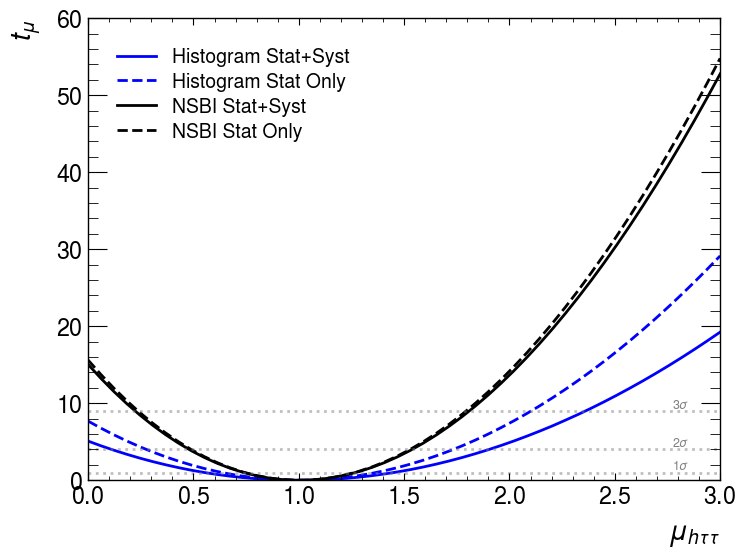

In [16]:
parameter_label = r'$\mu_{h\tau\tau}$'
list_scan_points = [scan_points_hist, scan_points_StatOnly_hist, scan_points_nsbi, scan_points_StatOnly_nsbi]
list_nll_values = [NLL_value_hist, NLL_value_StatOnly_hist, NLL_value_nsbi, NLL_value_StatOnly_nsbi]
list_labels = ["Histogram Stat+Syst", "Histogram Stat Only", "NSBI Stat+Syst", "NSBI Stat Only"]
list_linestyles = ["-", "--", "-", "--"]
list_colors = ["blue", "blue", "black", "black"]

nsbi_common_utils.inference.plot_NLL_scans(parameter_label, list_scan_points, list_nll_values, list_labels, list_linestyles, list_colors)

Optimizing the analysis
===

**As we increase the number of parameters, the robustness of the density ratio modelling becomes more important. Building ensembles and optimizing preselections are important. Each of the $O(100)$ nuisance paramters typical in an LHC analysis needs to be checked for bias.**

Things that can be optimized for better convergence:

- Generate more simulated events for better modelling.
- Tighter preselections - removing more of the background-rich phase space $p_{ref}\sim 0$ that can cause numerical instabilites, removing phase space regions with low Monte Carlo statistics or that are difficult to model, etc.
- Add more input features for easier signal-background separation.
- Changing the hyperparameters of the various NNs used in the modelling.
- Training ensembles of NNs
